## Plume Seasonality with NextGEMS - FESOM

In [1]:
# %pip install intake
# %pip install gribscan
# %pip install intake-xarray

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pylab as plt
import matplotlib.cm as cm
import cmocean.cm as cmo
from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, NearestNDInterpolator
import gribscan
import intake
# import uxarray as ux
from scipy.interpolate import griddata
from tqdm import tqdm

#### NextGEMS functions

In [3]:
def attach_coords(ds):
    model_lon = ds.lon.values
    model_lat = ds.lat.values
    return ds.assign_coords(
        lat = (("value",), model_lat, {"units": "degree_north"}),
        lon = (("value",), model_lon, {"units": "degree_east"}),
    )


def attach_depth_coords(ds):
    nz1  = [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5,
    62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5, 97.5, 105, 115, 125, 135, 145,
    155, 165, 175, 185, 195, 210, 230, 250, 270, 290, 320, 360, 400, 440,
    480, 520, 560, 600, 640, 710, 810, 950, 1110, 1255, 1415, 1600, 1810,
    2035, 2275, 2525, 2775, 3025, 3275, 3525, 3775, 4025, 4275, 4525, 4775,
    5025, 5275, 5525, 5825, 6175, 6175]
    nz = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85,
    90, 95, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 220, 240,
    260, 280, 300, 340, 380, 420, 460, 500, 540, 580, 620, 660, 760, 860,
    1040, 1180, 1330, 1500, 1700, 1920, 2150, 2400, 2650, 2900, 3150, 3400,
    3650, 3900, 4150, 4400, 4650, 4900, 5150, 5400, 5650, 6000, 6350]
    return ds.assign_coords(
        nz1 = (("level",), nz1, {"units": "m"}),
        nz = (("level",), nz, {"units": "m"}),
    )


nz1  = [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5,
    62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5, 97.5, 105, 115, 125, 135, 145,
    155, 165, 175, 185, 195, 210, 230, 250, 270, 290, 320, 360, 400, 440,
    480, 520, 560, 600, 640, 710, 810, 950, 1110, 1255, 1415, 1600, 1810,
    2035, 2275, 2525, 2775, 3025, 3275, 3525, 3775, 4025, 4275, 4525, 4775,
    5025, 5275, 5525, 5825, 6175, 6175]

nz = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85,
    90, 95, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 220, 240,
    260, 280, 300, 340, 380, 420, 460, 500, 540, 580, 620, 660, 760, 860,
    1040, 1180, 1330, 1500, 1700, 1920, 2150, 2400, 2650, 2900, 3150, 3400,
    3650, 3900, 4150, 4400, 4650, 4900, 5150, 5400, 5650, 6000, 6350]

### Processing Functions

In [4]:
def season_mean(data):

    ss = data['time'].dt.season
    ss_means = data.groupby(ss).mean('time')
    return ss_means

def monthly_mean(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Loading Data

### Choosing a model from NextGEMs

In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="zarr.core.metadata.v2")
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
list(cat)

['ICON', 'IFS', 'FESOM', 'ERA5', 'JRA3Q', 'MERRA2', 'IMERG', 'GSMaP']

In [6]:
list(cat.FESOM)

['IFS_4.4-FESOM_5-cycle3',
 'IFS_28-FESOM_25-cycle3',
 'IFS_9-FESOM_5-cycle3',
 'FESOM_13_tropo_age_interpolated']

In [7]:
list(cat.FESOM['IFS_4.4-FESOM_5-cycle3'])

['2D_1h_0.25deg',
 '2D_1h_1deg',
 '2D_1h_native',
 '2D_daily_0.25deg',
 '2D_daily_1deg',
 '2D_daily_native',
 '2D_monthly_0.25deg',
 '2D_monthly_1deg',
 '2D_monthly_native',
 '3D_3h_native',
 '3D_3h_native_zarr',
 '3D_daily_native',
 '3D_daily_native_zarr',
 '3D_monthly_0.25deg',
 '3D_monthly_1deg',
 'elem_grid',
 'node_grid',
 'data_inventory']

### Mesh Creation

In [8]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
## Mesh
# source = cat.FESOM["IFS_4.4-FESOM_5-cycle3"]["node_grid"]
# Load the native mesh (nodes)  
nodes = cat.FESOM["IFS_4.4-FESOM_5-cycle3"]["node_grid"].reader.read(engine="netcdf4", chunks={})
elems = cat.FESOM["IFS_4.4-FESOM_5-cycle3"]["elem_grid"].reader.read(engine="netcdf4", chunks={})

elems

<xarray.Dataset> Size: 2GB
Dimensions:          (grid_size: 14741520, grid_corners: 3, grid_rank: 1,
                      ncells: 7402886, nlinks_max: 8)
Dimensions without coordinates: grid_size, grid_corners, grid_rank, ncells,
                                nlinks_max
Data variables:
    grid_center_lon  (grid_size) float64 118MB dask.array<chunksize=(14741520,), meta=np.ndarray>
    grid_corner_lon  (grid_size, grid_corners) float64 354MB dask.array<chunksize=(14741520, 3), meta=np.ndarray>
    grid_center_lat  (grid_size) float64 118MB dask.array<chunksize=(14741520,), meta=np.ndarray>
    grid_corner_lat  (grid_size, grid_corners) float64 354MB dask.array<chunksize=(14741520, 3), meta=np.ndarray>
    grid_dims        (grid_rank) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    grid_imask       (grid_size) float64 118MB dask.array<chunksize=(14741520,), meta=np.ndarray>
    cell_area        (grid_size) float64 118MB dask.array<chunksize=(14741520,), meta=np.ndarray>
    node_node_links  (ncells, nlinks_max) float64 474MB dask.array<chunksize=(7402886, 8), meta=np.ndarray>
    triag_nodes      (grid_size, grid_corners) float64 354MB dask.array<chunksize=(14741520, 3), meta=np.ndarray>
    coast            (grid_size) float64 118MB dask.array<chunksize=(14741520,), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    history:      2022-03-19 08:26:26 GMT; Grid description file generated wi...

In [9]:
#to -180 - 180

# nodes["grid_center_lon"] = nodes["grid_center_lon"].where(nodes["grid_center_lon"] <= 180, other=nodes["grid_center_lon"] - 360)
nodes.grid_center_lon.compute()

<xarray.DataArray 'grid_center_lon' (grid_size: 7402886)> Size: 59MB
array([182.75159163, 182.69023354, 182.68546671, ..., 178.49163036,
       178.28238769, 178.28138628], shape=(7402886,))
Dimensions without coordinates: grid_size
Attributes:
    units:          degrees
    standard_name:  longitude
    bounds:         grid_corner_lon

In [10]:
## Create a mesh

# 1)Extraer nodos
lon_nodes = nodes['grid_center_lon'].data
lat_nodes = nodes['grid_center_lat'].data

# 2)Extraer elementos
face_nodes = elems['triag_nodes'].astype(int)  # (ntriags, 3)

face_nodes_T = face_nodes.transpose('grid_corners', 'grid_size')
face_nodes_T = face_nodes_T.rename({'grid_corners': 'n3', 'grid_size': 'elem'})

# 3)Crear Dataset simulado tipo FESOM
ds_mesh = xr.Dataset(
    coords={
        'nod2': ('nod2', np.arange(len(lon_nodes)) + 1),
        'elem': ('elem', np.arange(len(face_nodes)) + 1),
        'n3': ('n3', [0, 1, 2]), 
        'nz': ('nz', nz),
        'nz1': ('nz1', nz1)
    },
    data_vars={
        'lat': ('nod2', lat_nodes.compute()),
        'lon': ('nod2', lon_nodes.compute()),
        'face_nodes': (('n3', 'elem'), face_nodes_T.data.compute()),  # necesitas transponer para (3, elem)
        # 'nz1_depth': ('nz1', nodes['depth_lev'].data),   # opcional
    }
)

# ds_mesh.to_netcdf('IFS_4.4-FESOM_5-cycle3_mesh.nc')

In [11]:
elem_corner_lons = ds_mesh.lon.sel(nod2=ds_mesh.face_nodes)
elem_corner_lats = ds_mesh.lat.sel(nod2=ds_mesh.face_nodes)

elem_corner_lons
elem_corner_lats

<xarray.DataArray 'lat' (n3: 3, elem: 14741520)> Size: 354MB
array([[-78.09547211, -78.09547211, -78.05118113, ..., -77.66438078,
        -77.79325323, -77.84855478],
       [-78.07051367, -78.12237992, -77.99910232, ..., -77.68937816,
        -77.81741389, -77.81741389],
       [-78.05118113, -78.07051367, -78.02426051, ..., -77.63815229,
        -77.84855478, -77.86335343]], shape=(3, 14741520))
Coordinates:
    nod2     (n3, elem) int64 354MB 1 1 2 2 ... 7402879 7402881 7402884 7402886
  * elem     (elem) int64 118MB 1 2 3 4 ... 14741517 14741518 14741519 14741520
  * n3       (n3) int64 24B 0 1 2

In [12]:
display(elem_corner_lats.isel(elem=slice(None, 3)).compute().data)
display(elem_corner_lons.isel(elem=slice(None, 3)).compute().data)

array([[-78.09547211, -78.09547211, -78.05118113],
       [-78.07051367, -78.12237992, -77.99910232],
       [-78.05118113, -78.07051367, -78.02426051]])

array([[182.75159163, 182.75159163, 182.69023354],
       [182.9236129 , 182.92595833, 182.68546671],
       [182.69023354, 182.9236129 , 182.51779192]])

In [13]:
elem_center_lons = elem_corner_lons.mean("n3")
elem_center_lats = elem_corner_lats.mean("n3")

#### Ungluing

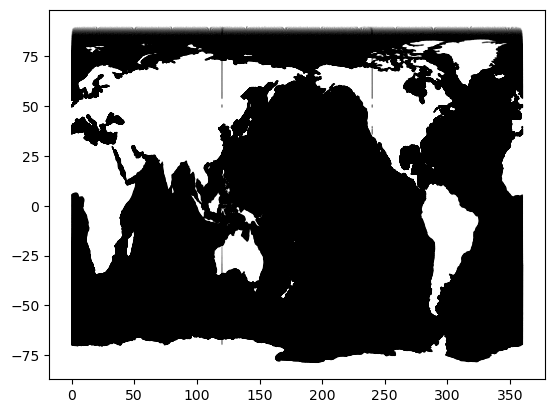

In [14]:
plt.scatter(elem_center_lons, elem_center_lats, s=1, alpha=0.05, edgecolor="none", facecolor="k")

In [17]:
tri_overlap=((elem_corner_lons.max('n3') - elem_corner_lons.min('n3'))>350)
tri_overlap

<xarray.DataArray 'lon' (elem: 14741520)> Size: 15MB
array([False, False, False, ..., False, False, False], shape=(14741520,))
Coordinates:
  * elem     (elem) int64 118MB 1 2 3 4 ... 14741517 14741518 14741519 14741520

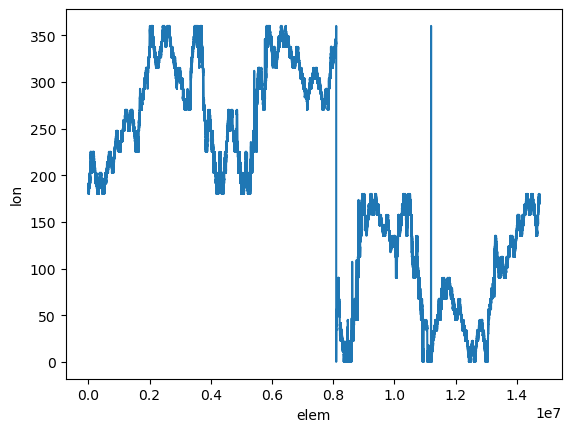

In [26]:
elem_corner_lons.max('n3').plot()

In [18]:
#350 degrees longitude is where they overlap
near_channel_width =350
channel_width = 360 ## total length of the channel (whole world)
elem_corner_lons_unglued = xr.where(tri_overlap & (elem_corner_lons > near_channel_width), 
                                   elem_corner_lons - channel_width, elem_corner_lons)
elem_corner_lons_unglued

<xarray.DataArray 'lon' (elem: 14741520, n3: 3)> Size: 354MB
array([[182.75159163, 182.9236129 , 182.69023354],
       [182.75159163, 182.92595833, 182.9236129 ],
       [182.69023354, 182.68546671, 182.51779192],
       ...,
       [178.27103597, 178.47677596, 178.47257689],
       [178.48570594, 178.28238769, 178.49163036],
       [178.49163036, 178.28238769, 178.28138628]], shape=(14741520, 3))
Coordinates:
  * elem     (elem) int64 118MB 1 2 3 4 ... 14741517 14741518 14741519 14741520
    nod2     (n3, elem) int64 354MB 1 1 2 2 ... 7402879 7402881 7402884 7402886
  * n3       (n3) int64 24B 0 1 2

In [19]:
elem_center_lons_unglued = elem_corner_lons_unglued.mean('n3')
elem_center_lats = elem_corner_lats.mean('n3')

elem_center_lons = elem_corner_lons.mean('n3')


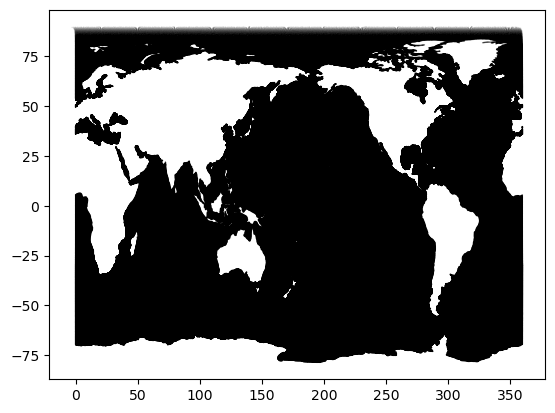

In [20]:
plt.scatter(elem_center_lons_unglued, elem_center_lats, s=1, alpha=0.05, edgecolor="none", facecolor="k")

In [21]:
ds_mesh = ds_mesh.assign_coords(
    elem_center_lons=elem_center_lons_unglued,
    elem_center_lats=elem_center_lats,
)

ds_mesh

<xarray.Dataset> Size: 885MB
Dimensions:           (nod2: 7402886, n3: 3, elem: 14741520, nz: 70, nz1: 70)
Coordinates:
  * nod2              (nod2) int64 59MB 1 2 3 4 ... 7402884 7402885 7402886
  * elem              (elem) int64 118MB 1 2 3 4 ... 14741518 14741519 14741520
  * n3                (n3) int64 24B 0 1 2
  * nz                (nz) int64 560B 0 5 10 15 20 ... 5150 5400 5650 6000 6350
  * nz1               (nz1) float64 560B 2.5 7.5 12.5 ... 6.175e+03 6.175e+03
    elem_center_lons  (elem) float64 118MB 182.8 182.9 182.6 ... 178.4 178.4
    elem_center_lats  (elem) float64 118MB -78.07 -78.1 -78.02 ... -77.82 -77.84
Data variables:
    lat               (nod2) float64 59MB -78.1 -78.05 -78.0 ... -77.82 -77.86
    lon               (nod2) float64 59MB 182.8 182.7 182.7 ... 178.3 178.3
    face_nodes        (n3, elem) int64 354MB 1 1 2 2 ... 7402881 7402884 7402886

In [25]:
ds_mesh['elem_center_lons'] = ds_mesh['elem_center_lons'].where(ds_mesh['elem_center_lons'] <= 180, other=ds_mesh['elem_center_lons'] - 360)
ds_mesh['lon'] = ds_mesh['lon'].where(ds_mesh['lon'] <= 180, other=ds_mesh['lon'] - 360)
ds_mesh

<xarray.Dataset> Size: 885MB
Dimensions:           (nod2: 7402886, n3: 3, elem: 14741520, nz: 70, nz1: 70)
Coordinates:
  * nod2              (nod2) int64 59MB 1 2 3 4 ... 7402884 7402885 7402886
  * elem              (elem) int64 118MB 1 2 3 4 ... 14741518 14741519 14741520
  * n3                (n3) int64 24B 0 1 2
  * nz                (nz) int64 560B 0 5 10 15 20 ... 5150 5400 5650 6000 6350
  * nz1               (nz1) float64 560B 2.5 7.5 12.5 ... 6.175e+03 6.175e+03
    elem_center_lons  (elem) float64 118MB -177.2 -177.1 -177.4 ... 178.4 178.4
    elem_center_lats  (elem) float64 118MB -78.07 -78.1 -78.02 ... -77.82 -77.84
Data variables:
    lat               (nod2) float64 59MB -78.1 -78.05 -78.0 ... -77.82 -77.86
    lon               (nod2) float64 59MB -177.2 -177.3 -177.3 ... 178.3 178.3
    face_nodes        (n3, elem) int64 354MB 1 1 2 2 ... 7402881 7402884 7402886

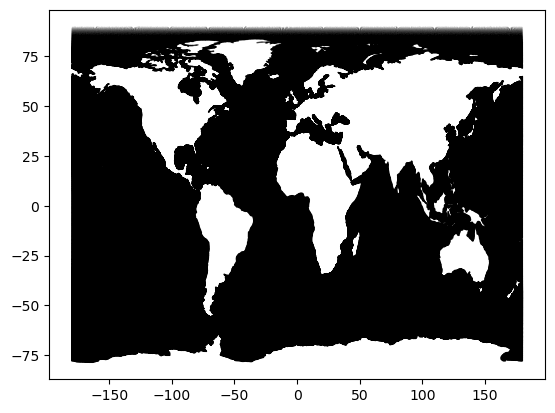

In [28]:
plt.scatter(ds_mesh['elem_center_lons'], ds_mesh['elem_center_lats'], s=1, alpha=0.05, edgecolor="none", facecolor="k")

In [62]:
# ds_mesh.to_netcdf('IFS_4.4-FESOM_5-cycle3_mesh.nc')

#### Xoak search

In [29]:
import xoak
ds_mesh.xoak.set_index(["elem_center_lats", "elem_center_lons"], "sklearn_geo_balltree")

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xoak/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [30]:
display(ds_mesh.lon.data.min(), ds_mesh.lon.data.max())

display(ds_mesh.lat.data.min(), ds_mesh.lat.data.max())

np.float64(-179.999914324336)

np.float64(179.999850601809)

np.float64(-78.618019336954)

np.float64(89.9944190470223)

In [31]:
grid_lon = xr.DataArray(np.linspace(-180, 180, 360*4), dims=("grid_lon", ))
grid_lat = xr.DataArray(np.linspace(-90, 90, 180*4), dims=("grid_lat", ))

In [32]:
target_lon, target_lat = xr.broadcast(grid_lon, grid_lat)

In [33]:
grid_elems = ds_mesh.xoak.sel(
    elem_center_lats=target_lat,
    elem_center_lons=target_lon,
).elem

grid_elems = grid_elems.assign_coords(
    target_lat=target_lat,
    target_lon=target_lon,
)

grid_elems = grid_elems.assign_coords(
    grid_lat=grid_lat,
    grid_lon=grid_lon,
)

grid_elems

<xarray.DataArray 'elem' (grid_lon: 1440, grid_lat: 720)> Size: 8MB
array([[  59748,   59748,   59748, ..., 5291536, 5291530, 5780576],
       [  59748,   59748,   59748, ..., 5291533, 5291530, 5780576],
       [  59748,   59748,   59748, ..., 5291533, 5291532, 5780576],
       ...,
       [  59748,   59748,   59748, ..., 5291536, 5291530, 5780576],
       [  59748,   59748,   59748, ..., 5291536, 5291530, 5780576],
       [  59748,   59748,   59748, ..., 5291536, 5291530, 5780576]],
      shape=(1440, 720))
Coordinates:
    elem              (grid_lon, grid_lat) int64 8MB 59748 59748 ... 5780576
    elem_center_lons  (grid_lon, grid_lat) float64 8MB -163.7 -163.7 ... -162.4
    elem_center_lats  (grid_lon, grid_lat) float64 8MB -78.6 -78.6 ... 89.97
    target_lat        (grid_lon, grid_lat) float64 8MB -90.0 -89.75 ... 90.0
    target_lon        (grid_lon, grid_lat) float64 8MB -180.0 -180.0 ... 180.0
  * grid_lat          (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.75 90.0
  * grid_lon          (grid_lon) float64 12kB -180.0 -179.7 ... 179.7 180.0

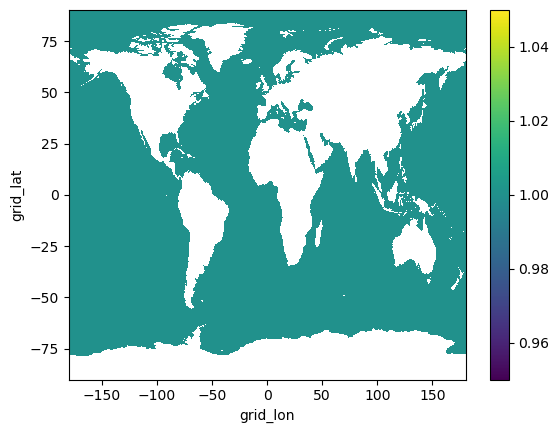

In [58]:
def haversine(lon1, lat1, lon2, lat2):
    """Great-circle distance in km."""
    R = 6371  # Earth radius in km
    dlon = np.deg2rad(lon2 - lon1)
    dlat = np.deg2rad(lat2 - lat1)
    a = np.sin(dlat/2)**2 + np.cos(np.deg2rad(lat1)) * np.cos(np.deg2rad(lat2)) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# Compute distances
dist = haversine(
    grid_elems.target_lon, grid_elems.target_lat,
    grid_elems.elem_center_lons, grid_elems.elem_center_lats
)

# Create mask (tune threshold; ~20-100 km typical for FESOM)
threshold = 9  # km
masknan = xr.where(dist < threshold, 1, np.nan)
masknan.plot(x='grid_lon')

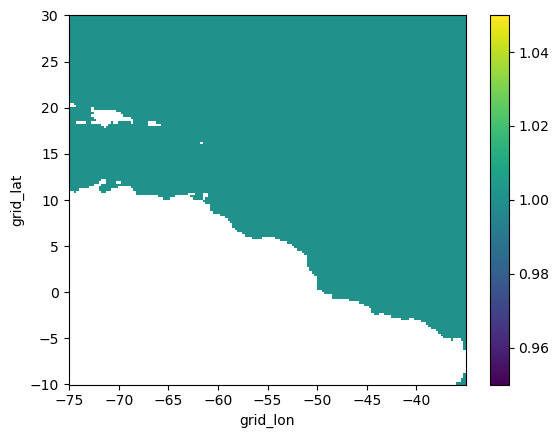

In [59]:
masknan.sel(grid_lon=slice(-75,-35),grid_lat=slice(-10,30)).plot(x='grid_lon')

In [61]:
# masknan.to_netcdf('mask_nan.nc')

In [21]:
# grid_elems.plot.imshow(x="grid_lon", y="grid_lat", size=5)

## FESOM Data

In [60]:
ds = cat.FESOM["IFS_4.4-FESOM_5-cycle3"]["3D_daily_native"].reader.read(
    engine="netcdf4",
    chunks={
    "time": -1,     # 1 month per chunk
    "nz1": 1,      # vertical levels (e.g., 10 levels per chunk)
    "elem": -1,  # coming from ncdump -hs /work/bm1235/a270046/cycle3/tco2559l137/hzfy/hres/intel.levante.openmpi/lvt.intel.sp/Cycle3_012020/u.fesom.2020.nc
    },
)
ds = ds[['u', 'v', 'salt']]
ds

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/intake/readers/readers.py:1313: UserWarning: The specified chunks separate the stored chunks along dimension "nz1" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return open_mfdataset(ofs, **kw)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/intake/readers/readers.py:1313: UserWarning: The specified chunks separate the stored chunks along dimension "nz1" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return open_mfdataset(ofs, **kw)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/intake/readers/readers.py:1313: UserWarning: The specified chunks separate the stored chunks along dimension "nz1" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return open_mfdataset(ofs, **kw)
/work/bk1450/b383184/conda/envs/pa

<xarray.Dataset> Size: 18TB
Dimensions:  (time: 1808, nz1: 69, elem: 14741520, nod2: 7402886)
Coordinates:
    lon      (nod2) float64 59MB dask.array<chunksize=(7402886,), meta=np.ndarray>
    lat      (nod2) float64 59MB dask.array<chunksize=(7402886,), meta=np.ndarray>
  * time     (time) datetime64[ns] 14kB 2020-01-20T23:56:00 ... 2024-12-31T23...
  * nz1      (nz1) float64 552B 2.5 7.5 12.5 ... 5.525e+03 5.825e+03 6.175e+03
Dimensions without coordinates: elem, nod2
Data variables:
    u        (time, nz1, elem) float32 7TB dask.array<chunksize=(12, 1, 14741520), meta=np.ndarray>
    v        (time, nz1, elem) float32 7TB dask.array<chunksize=(12, 1, 14741520), meta=np.ndarray>
    salt     (time, nz1, nod2) float32 4TB dask.array<chunksize=(12, 1, 321865), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    history:      2022-03-19 08:26:17 GMT; Grid description file generated wi...

### UV seasonality

In [24]:
from dask.distributed import Client
c=Client(n_workers = 3, threads_per_worker = 3)
c

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44345 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:44345/status,
Dashboard: http://127.0.0.1:44345/status,Workers: 3
Total threads: 9,Total memory: 50.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41955,Workers: 0
Dashboard: http://127.0.0.1:44345/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46407,Total threads: 3
Dashboard: http://127.0.0.1:41187/status,Memory: 16.67 GiB
Nanny: tcp://127.0.0.1:44089,


In [25]:
U_grid = ds.isel(nz1=0).u.isel(elem=grid_elems - 1)
V_grid = ds.isel(nz1=0).v.isel(elem=grid_elems - 1)
# U_grid.plot(x='grid_lon',y='grid_lat',robust=True)
V_grid.sel(grid_lon=slice(-75,-35),grid_lat=slice(-10,30))

UV = (U_grid**2 + V_grid**2)**0.5

# UV = UV.chunk({'time': 90, 'grid_lon': 480, 'grid_lat': 360})
UV = UV.compute()
UV

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 0.93 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-08-14 14:19:33,604 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 13.42 GiB -- Worker memory limit: 16.67 GiB
2025-08-14 14:19:36,036 - distributed.worker.memory - WARNING - Worker is at 68% memory usage. Resuming worker. Process memory: 11.36 GiB -- Worker memory limit: 16.67 GiB


<xarray.DataArray (time: 1808, grid_lon: 1440, grid_lat: 720)> Size: 7GB
array([[[0.0199983 , 0.0199983 , 0.0199983 , ..., 0.01958738,
         0.02116179, 0.02062676],
        [0.0199983 , 0.0199983 , 0.0199983 , ..., 0.01958738,
         0.02116179, 0.02062676],
        [0.0199983 , 0.0199983 , 0.0199983 , ..., 0.01958738,
         0.02116179, 0.02062676],
        ...,
        [0.0199983 , 0.0199983 , 0.0199983 , ..., 0.01958738,
         0.02116179, 0.02062676],
        [0.0199983 , 0.0199983 , 0.0199983 , ..., 0.01958738,
         0.02116179, 0.02062676],
        [0.0199983 , 0.0199983 , 0.0199983 , ..., 0.01958738,
         0.02116179, 0.02062676]],

       [[0.02851797, 0.02851797, 0.02851797, ..., 0.02185216,
         0.02244543, 0.02241565],
        [0.02851797, 0.02851797, 0.02851797, ..., 0.02185216,
         0.02244543, 0.02241565],
        [0.02851797, 0.02851797, 0.02851797, ..., 0.02185216,
         0.02244543, 0.02241565],
...
        [0.0423426 , 0.0423426 , 0.0423426 , ..., 0.0177483 ,
         0.02889849, 0.03489185],
        [0.0423426 , 0.0423426 , 0.0423426 , ..., 0.0177483 ,
         0.02889849, 0.03489185],
        [0.0423426 , 0.0423426 , 0.0423426 , ..., 0.0177483 ,
         0.02889849, 0.03489185]],

       [[0.0338405 , 0.0338405 , 0.0338405 , ..., 0.02141734,
         0.03206006, 0.03668073],
        [0.0338405 , 0.0338405 , 0.0338405 , ..., 0.02141734,
         0.03206006, 0.03668073],
        [0.0338405 , 0.0338405 , 0.0338405 , ..., 0.02141734,
         0.03206006, 0.03668073],
        ...,
        [0.0338405 , 0.0338405 , 0.0338405 , ..., 0.02141734,
         0.03206006, 0.03668073],
        [0.0338405 , 0.0338405 , 0.0338405 , ..., 0.02141734,
         0.03206006, 0.03668073],
        [0.0338405 , 0.0338405 , 0.0338405 , ..., 0.02141734,
         0.03206006, 0.03668073]]], shape=(1808, 1440, 720), dtype=float32)
Coordinates:
  * time              (time) datetime64[ns] 14kB 2020-01-20T23:56:00 ... 2024...
    nz1               float64 8B 2.5
    elem              (grid_lon, grid_lat) int64 8MB 59748 59748 ... 5780576
    elem_center_lons  (grid_lon, grid_lat) float64 8MB -163.7 -163.7 ... 77.6
    elem_center_lats  (grid_lon, grid_lat) float64 8MB -78.6 -78.6 ... 89.97
    target_lat        (grid_lon, grid_lat) float64 8MB -90.0 -89.75 ... 90.0
    target_lon        (grid_lon, grid_lat) float64 8MB -180.0 -180.0 ... 180.0
  * grid_lat          (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.75 90.0
  * grid_lon          (grid_lon) float64 12kB -180.0 -179.7 ... 179.7 180.0

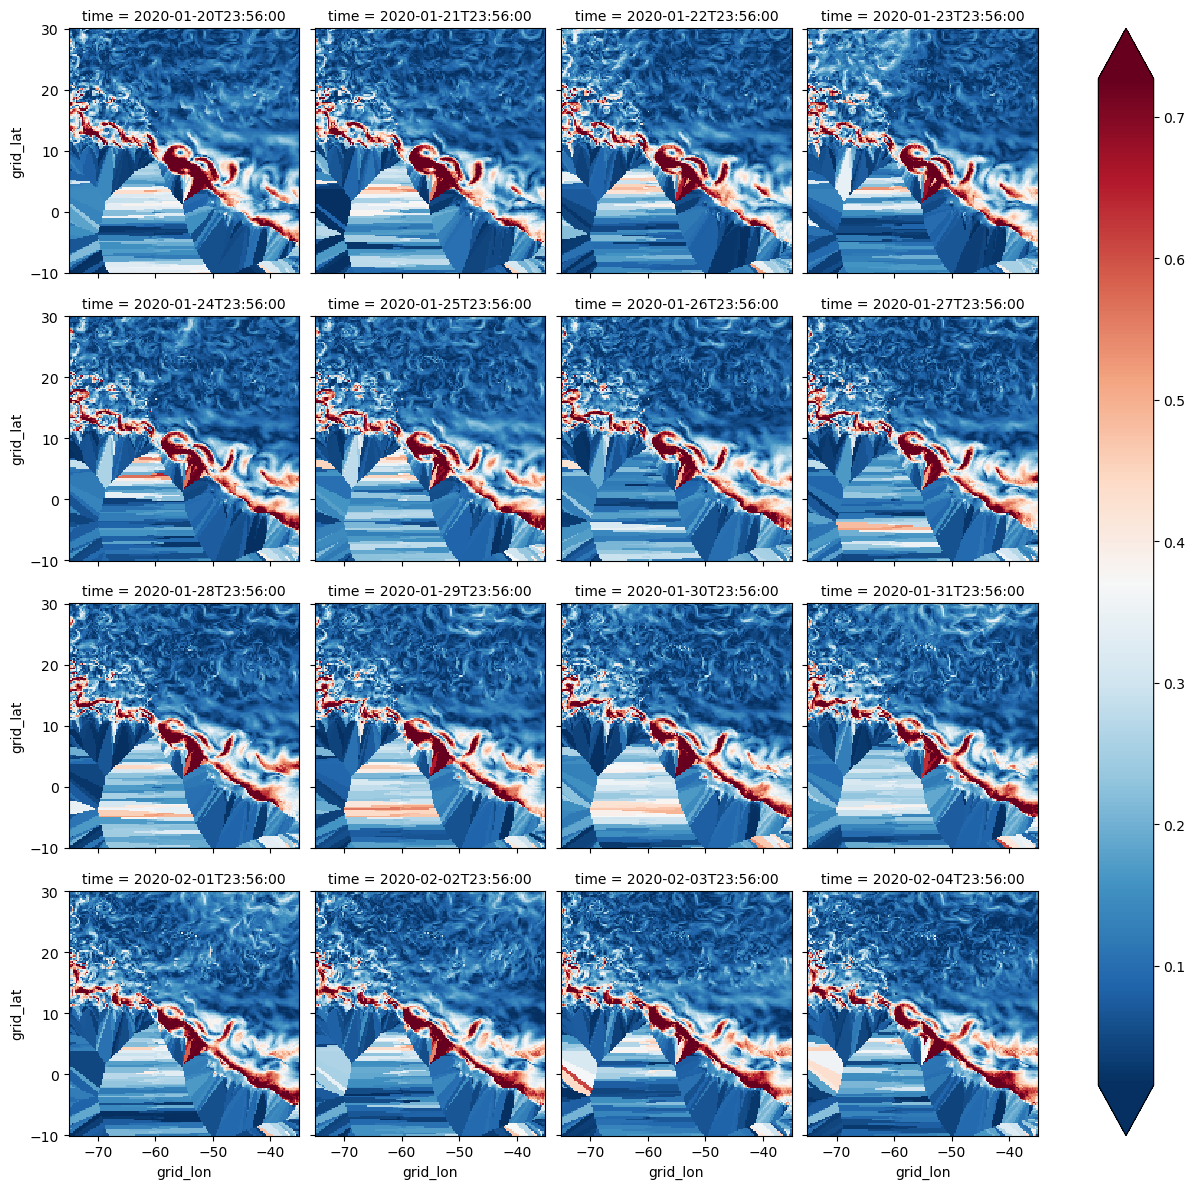

In [26]:
UV.sel(grid_lon=slice(-75,-35),grid_lat=slice(-10,30)).isel(time=slice(None, 16)).compute().plot(
    x="grid_lon", y="grid_lat", col="time", col_wrap=4, robust=True, cmap= 'RdBu_r')

In [27]:
# UV = UV.chunk({"time": 365}) 
uv_season = season_mean(UV)

uv_season=uv_season.compute()
uv_season.to_netcdf('uv_season.nc')

In [32]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy

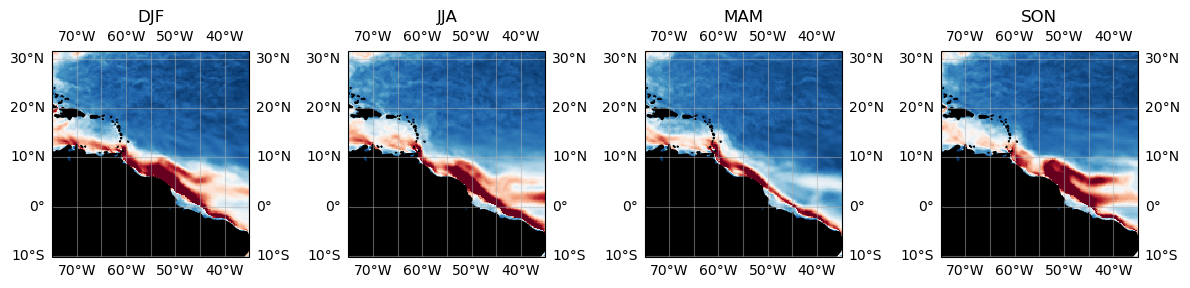

In [33]:
# Create subplots with cartopy projection
fig, axes = plt.subplots(1, 4, figsize=(12, 3), 
                        subplot_kw={'projection': ccrs.PlateCarree()})

# Get your data subset
data_subset = uv_season.sel(grid_lon=slice(-75,-35), grid_lat=slice(-10,32))

for i, season in enumerate(data_subset.season):
    ax = axes[i]
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAND, alpha=0.3)
    ax.add_feature(cfeature.OCEAN, alpha=0.3)
    
    # Plot data
    im = data_subset.sel(season=season).plot(
        ax=ax, x="grid_lon", y="grid_lat", 
        robust=True, cmap='RdBu_r',
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )
    
    ax.set_extent([-75, -35, -10, 30])
    ax.gridlines(draw_labels=True, alpha=0.5)
    ax.set_title(f'{season.values}')
    
    ax.add_feature(
    cartopy.feature.NaturalEarthFeature('physical','land','10m', facecolor='black'))
# Add single colorbar
# plt.colorbar(im, ax=axes, orientation='vertical', pad=0.1, shrink=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# uv_season.sel(grid_lon=slice(-75,-35),grid_lat=slice(-10,30)).plot(
#     x="grid_lon", y="grid_lat",col="season", col_wrap=4, robust=True,
#            figsize=(12, 3),cmap='RdBu_r',add_colorbar=True)

### Salinity

In [34]:
  ## modify the mesh for nodes and 
ds_mesh = ds_mesh.assign_coords(
        lat=("nod2", ds_mesh.lat.data.flatten()),
        lon=("nod2", ds_mesh.lon.data.flatten()),
    )
    # Ensure the xoak index 
ds_mesh.xoak.set_index(["lat", "lon"], "sklearn_geo_balltree")

#-------------get the nod2grids
grid_nodes = ds_mesh.xoak.sel(
        lat = target_lat,
        lon = target_lon,
    ).nod2
grid_nodes

<xarray.DataArray 'nod2' (grid_lon: 1440, grid_lat: 720)> Size: 8MB
array([[  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       ...,
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521]],
      shape=(1440, 720))
Coordinates:
    lat      (grid_lon, grid_lat) float64 8MB -78.62 -78.62 ... 89.77 89.99
    lon      (grid_lon, grid_lat) float64 8MB -163.6 -163.6 ... -178.7 -48.1
    nod2     (grid_lon, grid_lat) int64 8MB 29590 29590 ... 2648152 2897521
Dimensions without coordinates: grid_lon, grid_lat

In [35]:
ds_mesh

<xarray.Dataset> Size: 885MB
Dimensions:           (nod2: 7402886, n3: 3, elem: 14741520, nz: 70, nz1: 70)
Coordinates:
    lat               (nod2) float64 59MB -78.1 -78.05 -78.0 ... -77.82 -77.86
    lon               (nod2) float64 59MB -177.2 -177.3 -177.3 ... 178.3 178.3
  * nod2              (nod2) int64 59MB 1 2 3 4 ... 7402884 7402885 7402886
  * elem              (elem) int64 118MB 1 2 3 4 ... 14741518 14741519 14741520
  * n3                (n3) int64 24B 0 1 2
  * nz                (nz) int64 560B 0 5 10 15 20 ... 5150 5400 5650 6000 6350
  * nz1               (nz1) float64 560B 2.5 7.5 12.5 ... 6.175e+03 6.175e+03
    elem_center_lons  (elem) float64 118MB -177.2 -177.1 -177.4 ... 178.4 178.4
    elem_center_lats  (elem) float64 118MB -78.07 -78.1 -78.02 ... -77.82 -77.84
Data variables:
    face_nodes        (n3, elem) int64 354MB 1 1 2 2 ... 7402881 7402884 7402886

In [36]:
sal= ds.isel(nz1=0).salt.isel(nod2=grid_nodes - 1)
# sal_region = sal_region.compute()
sal 

<xarray.DataArray 'salt' (time: 1808, grid_lon: 1440, grid_lat: 720)> Size: 7GB
dask.array<transpose, shape=(1808, 1440, 720), dtype=float32, chunksize=(31, 447, 720), chunktype=numpy.ndarray>
Coordinates:
    lon      (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(1440, 720), meta=np.ndarray>
    lat      (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(1440, 720), meta=np.ndarray>
  * time     (time) datetime64[ns] 14kB 2020-01-20T23:56:00 ... 2024-12-31T23...
    nz1      float64 8B 2.5
    nod2     (grid_lon, grid_lat) int64 8MB 29590 29590 ... 2648152 2897521
Dimensions without coordinates: grid_lon, grid_lat
Attributes:
    description:  salinity
    long_name:    salinity
    units:        psu

In [38]:
sal['lon'] = UV.grid_lon
sal['lat'] = UV.grid_lat
salt = sal.compute()
salt

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 477.51 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-08-14 14:38:24,121 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 13.38 GiB -- Worker memory limit: 16.67 GiB
2025-08-14 14:38:26,510 - distributed.worker.memory - WARNING - Worker is at 74% memory usage. Resuming worker. Process memory: 12.45 GiB -- Worker memory limit: 16.67 GiB


<xarray.DataArray 'salt' (time: 1808, grid_lon: 1440, grid_lat: 720)> Size: 7GB
array([[[33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ],
        [33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ],
        [33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ],
        ...,
        [33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ],
        [33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ],
        [33.81737 , 33.81737 , 33.81737 , ..., 31.557405, 31.573921,
         31.59797 ]],

       [[33.829334, 33.829334, 33.829334, ..., 31.563124, 31.578127,
         31.600765],
        [33.829334, 33.829334, 33.829334, ..., 31.563124, 31.578127,
         31.600765],
        [33.829334, 33.829334, 33.829334, ..., 31.563124, 31.578127,
         31.600765],
...
        [32.778355, 32.778355, 32.778355, ..., 32.2894  , 32.334187,
         32.387913],
        [32.778355, 32.778355, 32.778355, ..., 32.2894  , 32.334187,
         32.387913],
        [32.778355, 32.778355, 32.778355, ..., 32.2894  , 32.334187,
         32.387913]],

       [[32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644],
        [32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644],
        [32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644],
        ...,
        [32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644],
        [32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644],
        [32.64432 , 32.64432 , 32.64432 , ..., 32.294212, 32.33596 ,
         32.390644]]], shape=(1808, 1440, 720), dtype=float32)
Coordinates:
    lon       (grid_lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
    lat       (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * time      (time) datetime64[ns] 14kB 2020-01-20T23:56:00 ... 2024-12-31T2...
    nz1       float64 8B 2.5
    nod2      (grid_lon, grid_lat) int64 8MB 29590 29590 ... 2648152 2897521
  * grid_lon  (grid_lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
  * grid_lat  (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
Attributes:
    description:  salinity
    long_name:    salinity
    units:        psu

In [40]:
sal_season = season_mean(salt)
sal_season

<xarray.DataArray 'salt' (season: 4, grid_lon: 1440, grid_lat: 720)> Size: 17MB
array([[[33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313],
        [33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313],
        [33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313],
        ...,
        [33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313],
        [33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313],
        [33.639633, 33.639633, 33.639633, ..., 31.957827, 31.996513,
         31.997313]],

       [[34.289906, 34.289906, 34.289906, ..., 30.634447, 30.726147,
         30.76405 ],
        [34.289906, 34.289906, 34.289906, ..., 30.634447, 30.726147,
         30.76405 ],
        [34.289906, 34.289906, 34.289906, ..., 30.634447, 30.726147,
         30.76405 ],
...
        [33.91393 , 33.91393 , 33.91393 , ..., 32.04419 , 32.085804,
         32.128872],
        [33.91393 , 33.91393 , 33.91393 , ..., 32.04419 , 32.085804,
         32.128872],
        [33.91393 , 33.91393 , 33.91393 , ..., 32.04419 , 32.085804,
         32.128872]],

       [[34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522],
        [34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522],
        [34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522],
        ...,
        [34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522],
        [34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522],
        [34.348667, 34.348667, 34.348667, ..., 31.331429, 31.323557,
         31.324522]]], shape=(4, 1440, 720), dtype=float32)
Coordinates:
    lon       (grid_lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
    lat       (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
    nz1       float64 8B 2.5
    nod2      (grid_lon, grid_lat) int64 8MB 29590 29590 ... 2648152 2897521
  * grid_lon  (grid_lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
  * grid_lat  (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * season    (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Attributes:
    description:  salinity
    long_name:    salinity
    units:        psu

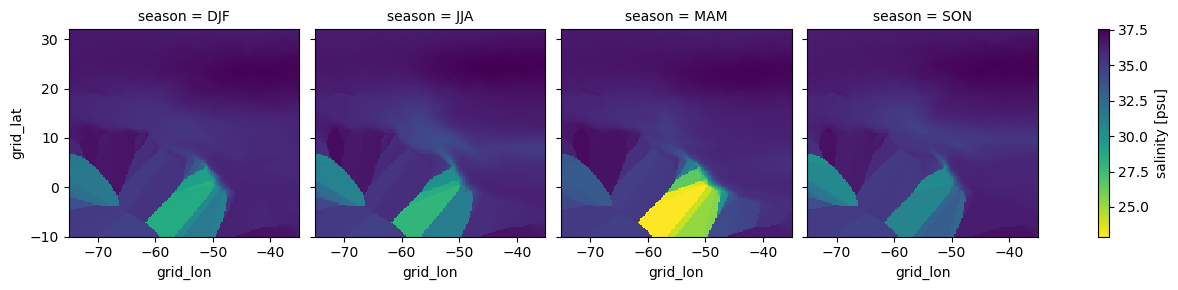

In [64]:
sal_season.sel(grid_lon=slice(-75,-35), grid_lat=slice(-10,32)).plot(
    x="grid_lon", y="grid_lat", col="season", col_wrap=4,cmap='viridis_r')

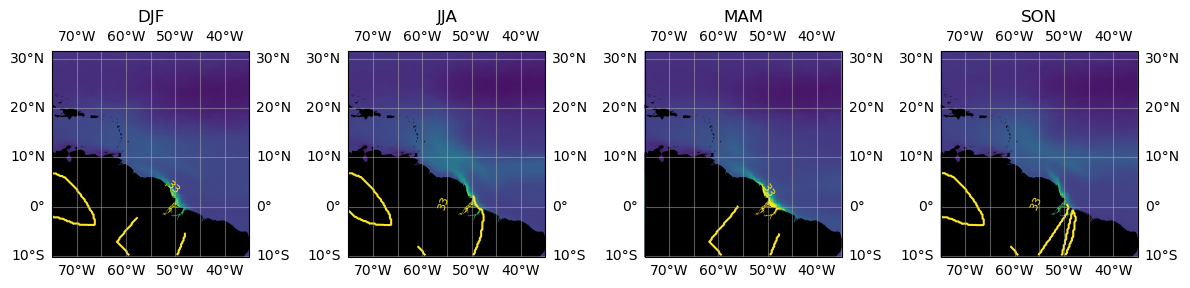

In [65]:
# Create subplots with cartopy projection
fig, axes = plt.subplots(1, 4, figsize=(12, 3), 
                        subplot_kw={'projection': ccrs.PlateCarree()})

for i, season in enumerate(sal_season.season):
    ax = axes[i]
    
    # Add map features
    
    # Plot data
    im = sal_season.sel(season=season).plot(
        ax=ax, x="grid_lon", y="grid_lat", 
        vmin=28,vmax=38, cmap='viridis_r',
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )

    cs = sal_season.sel(grid_lon=slice(-75,-35), grid_lat=slice(-10,32),season=season).plot.contour(ax=ax,
    x="grid_lon", y="grid_lat",levels=[33])

    
    # Optional: Add contour labels
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.f')
    
    ax.set_extent([-75, -35, -10, 30])
    ax.gridlines(draw_labels=True, alpha=0.5)
    ax.set_title(f'{season.values}')
    
    ax.add_feature(
    cartopy.feature.NaturalEarthFeature('physical','land','10m', facecolor='black'))
# Add single colorbar
# plt.colorbar(im, ax=axes, orientation='vertical', pad=0.1, shrink=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# sal.sel(grid_lon=slice(-75,-35),grid_lat=slice(-10,30)).isel(time=0).plot(
#     x="grid_lon", y="grid_lat",cmap='viridis_r')

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy

# Selección de la región y el primer timestep
sal_map = sal.sel(grid_lon=slice(-75, -35), grid_lat=slice(-10, 30)).isel(time=0)

# Crear figura y ejes con proyección
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Establecer fondo blanco
# ax.set_facecolor("white")

# Agregar datos
sal_map.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x='grid_lon',
    y='grid_lat',
    cmap='viridis_r',
    cbar_kwargs={'label': 'UPS'},
    robust=True,levels=20
)

land = ax.add_feature(
    cartopy.feature.NaturalEarthFeature('physical','land','10m', facecolor='black'))

# Añadir detalles del mapa
ax.coastlines()
ax.set_title('Salinity')
ax.set_extent([-75, -35, -10, 30], crs=ccrs.PlateCarree())

plt.show()


## Monthly mean

In [ ]:
sal_month = monthly_mean(ds_subset.sel(value=pnts.values).avg_so)
sal_month

In [ ]:
sal_m = get_data(sal_month, points, lats, lons, method='linear')
sal_m

In [ ]:
g = sal_m.plot.contourf(col="month", col_wrap=4, robust=True, 
                                     figsize=(12, 9),cmap='viridis_r',add_colorbar=True, levels=20)

# Add 30 psu contour lines to each subplot
for ax, month in zip(g.axs.flat, sal_m.month.values):  # Use g.axs instead of g.axes
    # Select 2D data for this specific season
    season_data = sal_m.sel(month=month)
    
    # Squeeze to ensure 2D (remove any singleton dimensions)
    contour_data = season_data.squeeze()
    
    # Plot contour
    cs = ax.contour(
        contour_data.lon, 
        contour_data.lat, 
        contour_data,
        levels=[33],
        colors='black',
        linewidths=1.5,
        linestyles='--'
    )
    # Optional: Add contour labels
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.f')

# Adjust layout and add title
plt.suptitle("Plume Extension Monthly Mean", y=1.02)
# plt.tight_layout()
# plt.savefig('Figures/Sal_season'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

### UV monthly mean

In [ ]:
uv_month = monthly_mean(uv)
uv_month

In [ ]:
uv_m = get_data(uv_month, points, lats, lons, method='linear')
uv_m

In [ ]:
uv_m.plot(col="month", col_wrap=4, robust=True,
           figsize=(12, 9),cmap='RdBu_r',add_colorbar=True)

### Alternative with uxarray

In [ ]:
# ds_subset["lon"] = ds_subset["lon"].where(ds_subset["lon"] <= 180, other=ds_subset["lon"] - 360)

In [ ]:
lon = ds_subset.lon.compute()
lat = ds_subset.lat.compute()

In [ ]:
lon.data.min(), lon.data.max()

In [ ]:
ds_subset.v.compute()

In [ ]:
## define the amazon plume region 
lon_min, lon_max = -75, -35.0  
lat_min, lat_max = -10.0, 30.0  

In [ ]:
mesh_nodes["grid_center_lon"] = mesh_nodes["grid_center_lon"].where(mesh_nodes["grid_center_lon"] <= 180, other=mesh_nodes["grid_center_lon"] - 360)
# mesh_nodes.grid_center_lon.compute()

mesh_elems["grid_center_lon"] = mesh_elems["grid_center_lon"].where( mesh_elems["grid_center_lon"] <= 180, other= mesh_elems["grid_center_lon"] - 360)
mesh_elems.grid_center_lon.compute()

In [ ]:
# Mask for nodes inside the bounding box
node_mask = (
    (mesh_nodes.grid_center_lon >= lon_min) & 
    (mesh_nodes.grid_center_lon <= lon_max) & 
    (mesh_nodes.grid_center_lat >= lat_min) & 
    (mesh_nodes.grid_center_lat <= lat_max)
)

node_mask = node_mask.compute() 
# Get indices of nodes in the area
node_indices =mesh_nodes.grid_size.where(node_mask, drop=True)  # shape: (n_nodes_in_region,)

node_indices

In [ ]:
## Elements mask
elem_mask = (
    (mesh_elems.grid_center_lon >= lon_min) & 
    (mesh_elems.grid_center_lon <= lon_max) & 
    (mesh_elems.grid_center_lat >= lat_min) & 
    (mesh_elems.grid_center_lat <= lat_max)
)

elem_mask = elem_mask.compute()
# Get indices of elements in the area
elem_indices = mesh_elems.grid_size.where(elem_mask, drop=True)  # shape: (n_elems_in_region,)

elem_indices